# Notebook 2 — Visualization of Option Surfaces

This notebook builds rich 2D and 3D visualizations of European option pricing and Greeks under the Black-Scholes model. We cover:

1. **Price vs Spot** — call and put payoff curves
2. **Delta and Gamma vs Spot** — first- and second-order sensitivities
3. **Price surface** $V(S, T)$ — 3D mesh over spot and maturity
4. **Delta heatmap** $\Delta(S, T)$
5. **Implied-volatility surface** — from a toy smile model
6. **Price surface with GBM paths** — option value evolving along simulated trajectories
7. **Delta surface with GBM paths** — hedge ratio along the same trajectories
8. **Put-call parity residual** — numerical verification
9. **Monte Carlo convergence** — MC price $\to$ BS closed-form as $N \to \infty$

In [1]:
import optpricer as op

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D surfaces

import optpricer as op

# Base contract / market setup (edit as desired)
S0   = 100.0
K    = 100.0
T    = 1.00   # years
r    = 0.03
q    = 0.00
sig  = 0.20

base = op.OptionSpec(S0=S0, K=K, T=T, r=r, sigma=sig, q=q)

# Common grids
S_vals = np.linspace(0.5*S0, 1.5*S0, 161)
T_vals = np.linspace(1/365, 2.0, 121)   # ~1 trading day to 2y
K_vals = np.linspace(0.6*S0, 1.4*S0, 81)


## Setup

We define a base ATM option and build common grids over spot $S$, maturity $T$, and strike $K$ that will be reused across all plots below.

In [3]:
S_vals

array([ 50.   ,  50.625,  51.25 ,  51.875,  52.5  ,  53.125,  53.75 ,
        54.375,  55.   ,  55.625,  56.25 ,  56.875,  57.5  ,  58.125,
        58.75 ,  59.375,  60.   ,  60.625,  61.25 ,  61.875,  62.5  ,
        63.125,  63.75 ,  64.375,  65.   ,  65.625,  66.25 ,  66.875,
        67.5  ,  68.125,  68.75 ,  69.375,  70.   ,  70.625,  71.25 ,
        71.875,  72.5  ,  73.125,  73.75 ,  74.375,  75.   ,  75.625,
        76.25 ,  76.875,  77.5  ,  78.125,  78.75 ,  79.375,  80.   ,
        80.625,  81.25 ,  81.875,  82.5  ,  83.125,  83.75 ,  84.375,
        85.   ,  85.625,  86.25 ,  86.875,  87.5  ,  88.125,  88.75 ,
        89.375,  90.   ,  90.625,  91.25 ,  91.875,  92.5  ,  93.125,
        93.75 ,  94.375,  95.   ,  95.625,  96.25 ,  96.875,  97.5  ,
        98.125,  98.75 ,  99.375, 100.   , 100.625, 101.25 , 101.875,
       102.5  , 103.125, 103.75 , 104.375, 105.   , 105.625, 106.25 ,
       106.875, 107.5  , 108.125, 108.75 , 109.375, 110.   , 110.625,
       111.25 , 111.

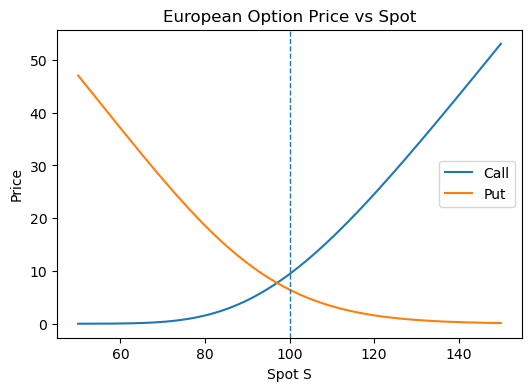

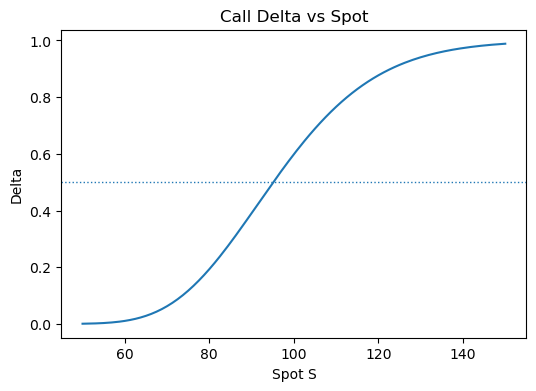

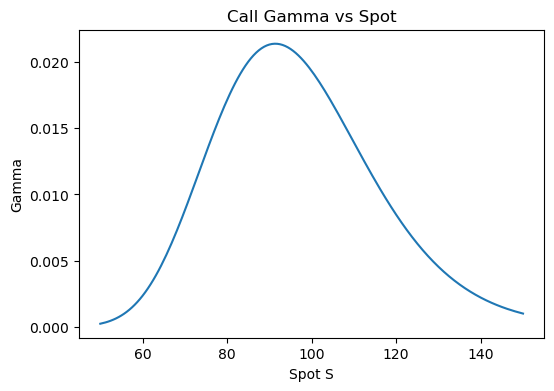

In [4]:
# Price vs Spot
call_px = op.bs_price_vec(S_vals, K, T, r, q, sig, op.CALL)
put_px  = op.bs_price_vec(S_vals, K, T, r, q, sig, op.PUT)

plt.figure(figsize=(6,4))
plt.plot(S_vals, call_px, label="Call")
plt.plot(S_vals, put_px,  label="Put")
plt.axvline(K, linestyle="--", linewidth=1)
plt.xlabel("Spot S"); plt.ylabel("Price"); plt.title("European Option Price vs Spot")
plt.legend(); plt.show()

# Greeks vs Spot (Delta & Gamma for a call)
g = op.bs_greeks_vec(S_vals, K, T, r, q, sig, op.CALL)
delta_call, gamma_call = g["delta"], g["gamma"]

plt.figure(figsize=(6,4))
plt.plot(S_vals, delta_call)
plt.axhline(0.5, linestyle=":", linewidth=1)
plt.xlabel("Spot S"); plt.ylabel("Delta"); plt.title("Call Delta vs Spot"); plt.show()

plt.figure(figsize=(6,4))
plt.plot(S_vals, gamma_call)
plt.xlabel("Spot S"); plt.ylabel("Gamma"); plt.title("Call Gamma vs Spot"); plt.show()


## 1. Price vs Spot & Greeks vs Spot

**Top**: Call and put prices as a function of spot $S$ (strike $K=100$ shown as dashed line). The call is monotonically increasing in $S$; the put is decreasing.

**Middle**: Delta ($\partial V / \partial S$) — the call delta ranges from 0 to 1 and transitions steeply near $S = K$.

**Bottom**: Gamma ($\partial^2 V / \partial S^2$) — largest near the money, where delta changes fastest, and this is where a delta-hedger must rebalance most frequently. The peak sits below the strike, not at it: gamma is maximized where $d_1 = -\sigma\sqrt{T}$, i.e. at $S = K e^{-(r - q + 3\sigma^2/2)T} \approx 91$ for these inputs.

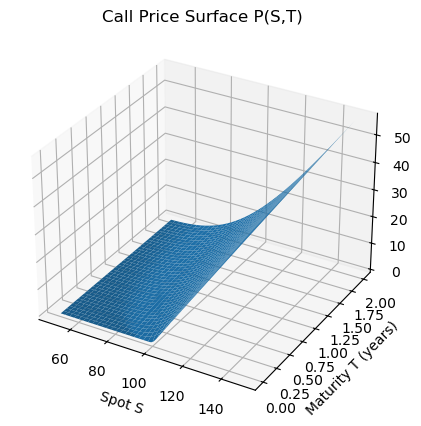

In [5]:
Sg, Tg = np.meshgrid(S_vals, T_vals, indexing="xy")
Z = op.bs_price_vec(Sg, K, Tg, r, q, sig, op.CALL)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Sg, Tg, Z, linewidth=0, antialiased=True)
ax.set_xlabel("Spot S"); ax.set_ylabel("Maturity T (years)"); ax.set_zlabel("Price")
ax.set_title("Call Price Surface P(S,T)")
plt.show()


## 2. Call Price Surface $V(S, T)$

A 3D surface showing how the European call value varies jointly with spot and maturity. As $T \to 0$, the surface converges to the intrinsic value $\max(S - K, 0)$. Longer maturities add more time value, especially near ATM.

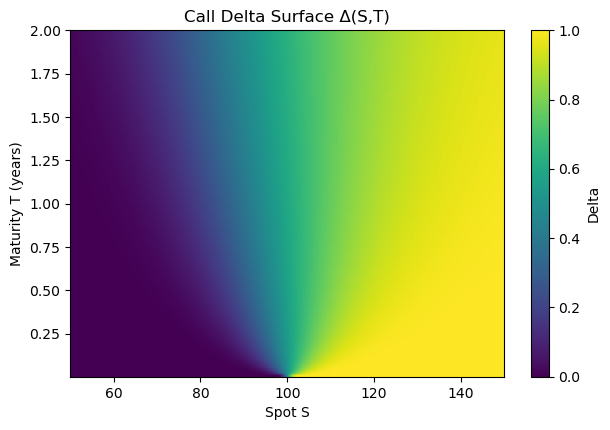

In [6]:
Delta = op.bs_greeks_vec(Sg, K, Tg, r, q, sig, op.CALL)["delta"]

plt.figure(figsize=(7,4.5))
plt.imshow(Delta, origin="lower", aspect="auto",
           extent=[S_vals.min(), S_vals.max(), T_vals.min(), T_vals.max()])
plt.colorbar(label="Delta")
plt.xlabel("Spot S"); plt.ylabel("Maturity T (years)")
plt.title("Call Delta Surface Δ(S,T)")
plt.show()


## 3. Delta Heatmap $\Delta(S, T)$

The color intensity shows the hedge ratio across spot and maturity. Near expiry (small $T$), delta transitions sharply from 0 to 1 at $S = K$. With more time remaining, the transition is smoother — reflecting the greater uncertainty about finishing in/out of the money.

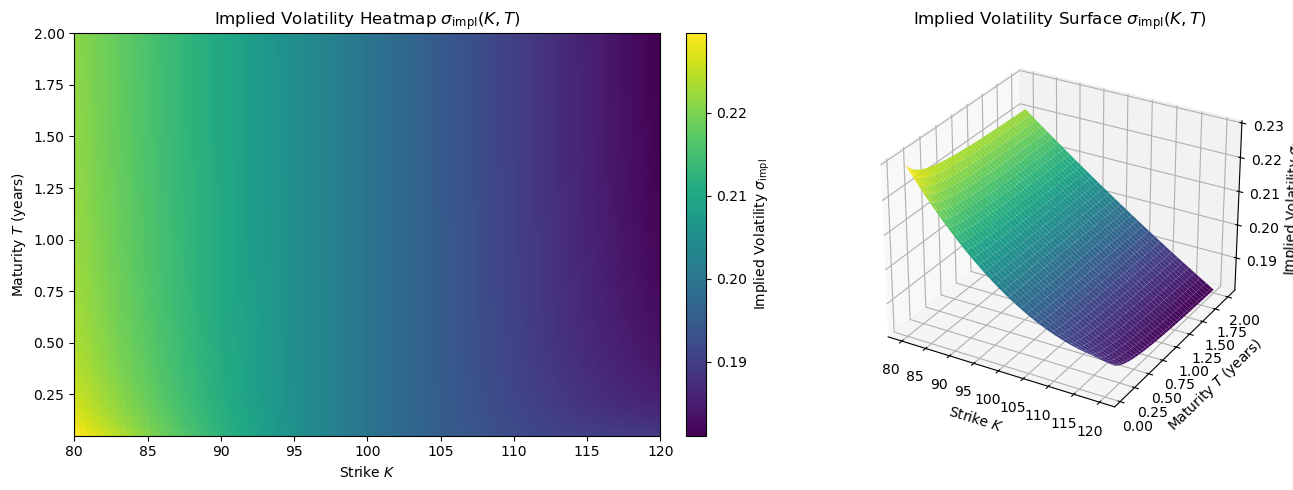

In [7]:
# Cell 5b — Implied Vol Surface (robust + LaTeX titles)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import optpricer as op

S0 = globals().get("S0", 100.0)
r  = globals().get("r", 0.03)
q  = globals().get("q", 0.00)

K_vals = np.linspace(0.8*S0, 1.2*S0, 101)   # 80%–120% moneyness
T_vals = np.linspace(0.05, 2.0, 121)        # 0.05y to 2 years

def toy_smile_sigma(S, K, T, base=0.20, skew=-0.10, curvature=0.30, floor=0.05):
    m = K / S - 1.0
    sig = base + skew*m + curvature*m*m*(1.0/(1.0+5*T))
    return np.maximum(floor, sig)

K_mesh, T_mesh = np.meshgrid(K_vals, T_vals, indexing="xy")

# Build the whole surface in three vectorized calls: true vol -> price -> recovered vol.
sig_true = toy_smile_sigma(S0, K_mesh, T_mesh)
px_mkt   = op.bs_price_vec(S0, K_mesh, T_mesh, r, q, sig_true, op.CALL)
IV       = op.bs_implied_vol_vec(S0, K_mesh, T_mesh, r, q, px_mkt, op.CALL)
Z = np.ma.masked_invalid(IV)

fig = plt.figure(figsize=(14,5))

# Heatmap
ax1 = fig.add_subplot(1, 2, 1)
im = ax1.imshow(Z, origin="lower", aspect="auto",
                extent=[K_vals.min(), K_vals.max(), T_vals.min(), T_vals.max()],
                cmap="viridis")
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label(r"Implied Volatility $\sigma_{\text{impl}}$")
ax1.set_xlabel(r"Strike $K$")
ax1.set_ylabel(r"Maturity $T$ (years)")
ax1.set_title(r"Implied Volatility Heatmap $\sigma_{\text{impl}}(K,T)$")

# 3D surface
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf = ax2.plot_surface(K_mesh, T_mesh, Z, cmap="viridis", linewidth=0, antialiased=True)
ax2.set_xlabel(r"Strike $K$")
ax2.set_ylabel(r"Maturity $T$ (years)")
ax2.set_zlabel(r"Implied Volatility $\sigma_{\text{impl}}$")
ax2.set_title(r"Implied Volatility Surface $\sigma_{\text{impl}}(K,T)$")
ax2.view_init(elev=28, azim=-60)

plt.tight_layout()
plt.show()


## 4. Implied Volatility Surface $\sigma_{\mathrm{impl}}(K, T)$

We construct a synthetic IV surface from a toy parametric model with skew and curvature (the "smirk" shape commonly seen in equity markets). The surface is displayed as both a heatmap and a 3D mesh.

Key features to observe:
- **Skew**: OTM puts (low $K$) have higher implied vol than OTM calls (high $K$)
- **Term structure**: The smile flattens at longer maturities
- **Curvature**: A convex "wings-up" shape at short tenors

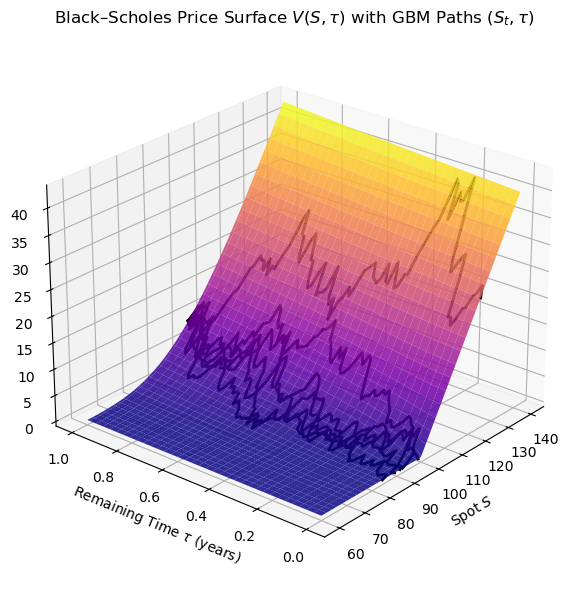

In [8]:
# Cell A — Price surface V(S, τ) with GBM paths (risk-neutral)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import optpricer as op

# Use globals from earlier cells if present; otherwise set defaults
S0 = globals().get("S0", 100.0)
K  = globals().get("K",  100.0)
T  = globals().get("T",    1.00)  # years
r  = globals().get("r",    0.03)
q  = globals().get("q",    0.00)
sig= globals().get("sig",  0.20)

# ----- grid for surface (spot S vs remaining time τ) -----
S_vals  = np.linspace(0.6*S0, 1.4*S0, 121)
Tau_vals= np.linspace(1e-4, T, 101)  # τ = time-to-maturity
Sg, Tg = np.meshgrid(S_vals, Tau_vals, indexing="xy")

V = op.bs_price_vec(Sg, K, Tg, r, q, sig, op.CALL)

# ----- simulate risk-neutral GBM paths S_t (drift = r - q) -----
def gbm_paths(S0, r, q, sigma, T, steps, n_paths, seed=None):
    rng = np.random.default_rng(seed)
    dt = T/steps
    nudt = (r - q - 0.5*sigma**2)*dt
    sdt  = sigma*np.sqrt(dt)
    # increments and cumulative log-returns
    Z = rng.standard_normal((n_paths, steps))
    logS = np.log(S0) + np.cumsum(nudt + sdt*Z, axis=1)
    S = np.concatenate([np.full((n_paths,1), S0), np.exp(logS)], axis=1)
    t = np.linspace(0.0, T, steps+1)
    return t, S

steps   = 100
n_paths = 6
t, S_paths = gbm_paths(S0, r, q, sig, T, steps, n_paths, seed=42)
Tau_path = T - t  # remaining time along each path

# option value along each path
# S_paths is (n_paths, steps+1) and Tau_path is (steps+1,) -- broadcasts directly.
V_paths = op.bs_price_vec(S_paths, K, np.maximum(Tau_path, 1e-8), r, q, sig, op.CALL)

# ----- plot: surface + trajectories -----
fig = plt.figure(figsize=(8.5,6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Sg, Tg, V, cmap="plasma", linewidth=0, antialiased=True, alpha=0.85)

# overlay paths
for k in range(n_paths):
    ax.plot(S_paths[k], Tau_path, V_paths[k], color="black", linewidth=2)

ax.set_xlabel(r"Spot $S$")
ax.set_ylabel(r"Remaining Time $\tau$ (years)")
ax.set_zlabel(r"Price $V(S,\tau)$")
ax.set_title(r"Black–Scholes Price Surface $V(S,\tau)$ with GBM Paths $(S_t,\tau)$")
ax.view_init(elev=25, azim=220)
plt.tight_layout()
plt.show()


## 5. Price Surface with GBM Paths

This is one of the most instructive visualizations in option pricing. The translucent surface is the Black-Scholes call price $V(S, \tau)$ as a function of spot and remaining time $\tau = T - t$. The black curves are **simulated GBM trajectories** — each path traces a point $(S_t, \tau, V(S_t, \tau))$ on the surface over time.

As $\tau \to 0$, all paths converge to the terminal payoff $\max(S_T - K, 0)$.

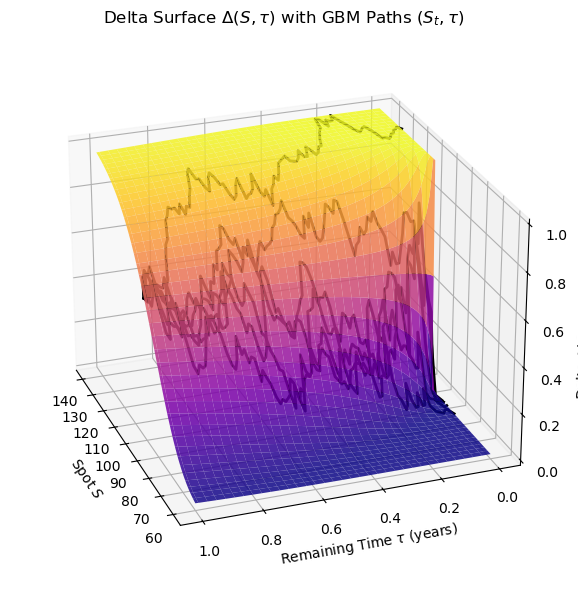

In [9]:
# Cell B — Delta surface Δ(S, τ) with GBM paths (risk-neutral)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import optpricer as op

# Reuse S_vals, Tau_vals if defined; else set them
S_vals  = globals().get("S_vals",  np.linspace(0.6*S0, 1.4*S0, 121))
Tau_vals= globals().get("Tau_vals",np.linspace(1e-4, T, 101))
Sg, Tg = np.meshgrid(S_vals, Tau_vals, indexing="xy")

Delta = op.bs_greeks_vec(Sg, K, Tg, r, q, sig, op.CALL)["delta"]

# If A's paths exist, reuse; otherwise generate
if "S_paths" not in globals():
    def gbm_paths(S0, r, q, sigma, T, steps, n_paths, seed=None):
        rng = np.random.default_rng(seed)
        dt = T/steps
        nudt = (r - q - 0.5*sigma**2)*dt
        sdt  = sigma*np.sqrt(dt)
        Z = rng.standard_normal((n_paths, steps))
        logS = np.log(S0) + np.cumsum(nudt + sdt*Z, axis=1)
        S = np.concatenate([np.full((n_paths,1), S0), np.exp(logS)], axis=1)
        t = np.linspace(0.0, T, steps+1)
        return t, S
    t, S_paths = gbm_paths(S0, r, q, sig, T, steps=100, n_paths=6, seed=42)

Tau_path = T - t
Delta_paths = op.bs_greeks_vec(S_paths, K, np.maximum(Tau_path, 1e-8),
                               r, q, sig, op.CALL)["delta"]

# Plot
fig = plt.figure(figsize=(8.5,6))
ax = fig.add_subplot(111, projection="3d")
# surf = ax.plot_surface(Sg, Tg, Delta, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
surf = ax.plot_surface(Sg, Tg, Delta, cmap="plasma", linewidth=0, antialiased=True, alpha=0.85)

for k in range(S_paths.shape[0]):
    ax.plot(S_paths[k], Tau_path, Delta_paths[k], color='black', linewidth=2)

ax.set_xlabel(r"Spot $S$")
ax.set_ylabel(r"Remaining Time $\tau$ (years)")
ax.set_zlabel(r"Delta $\Delta(S,\tau)$")
ax.set_title(r"Delta Surface $\Delta(S,\tau)$ with GBM Paths $(S_t,\tau)$")
ax.view_init(elev=25, azim=-200)
plt.tight_layout()
plt.show()


## 6. Delta Surface with GBM Paths

The same idea applied to the hedge ratio $\Delta(S, \tau)$. The black curves show how much stock a delta-hedger would need to hold at each point in time. Near expiry, the hedge ratio "snaps" to 0 or 1 — this is when gamma risk is highest and hedging is most expensive.

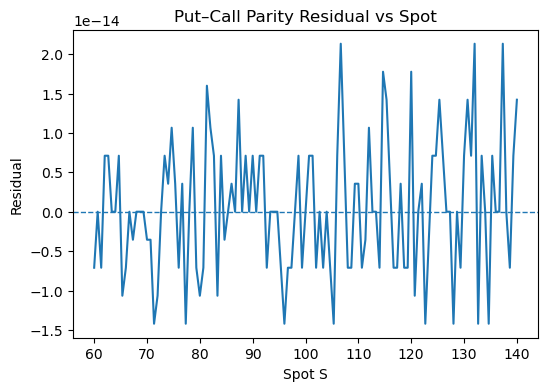

In [10]:
c = op.bs_price_vec(S_vals, K, T, r, q, sig, op.CALL)
p = op.bs_price_vec(S_vals, K, T, r, q, sig, op.PUT)
parity_resid = c - p - (S_vals*np.exp(-q*T) - K*np.exp(-r*T))

plt.figure(figsize=(6,4))
plt.plot(S_vals, parity_resid)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot S"); plt.ylabel("Residual")
plt.title("Put–Call Parity Residual vs Spot")
plt.show()


## 7. Put-Call Parity Verification

Put-call parity states:

$$C(S) - P(S) = S e^{-qT} - K e^{-rT}$$

The residual should be zero (up to floating-point precision, $\sim 10^{-14}$). This is a basic sanity check for any pricing implementation.

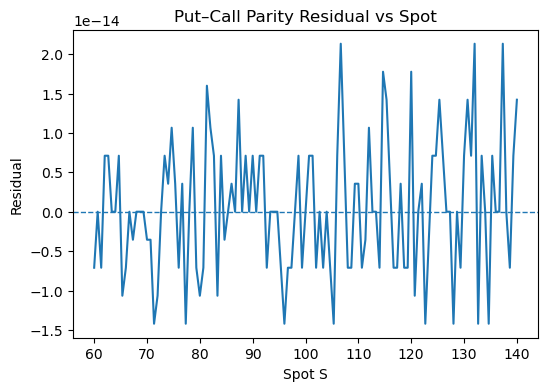

In [11]:
c = op.bs_price_vec(S_vals, K, T, r, q, sig, op.CALL)
p = op.bs_price_vec(S_vals, K, T, r, q, sig, op.PUT)
parity_resid = c - p - (S_vals*np.exp(-q*T) - K*np.exp(-r*T))

plt.figure(figsize=(6,4))
plt.plot(S_vals, parity_resid)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot S"); plt.ylabel("Residual")
plt.title("Put–Call Parity Residual vs Spot")
plt.show()


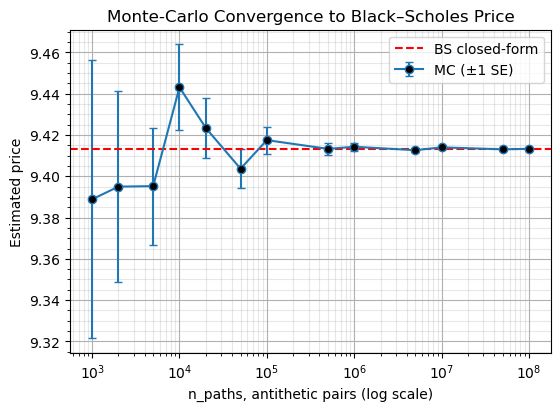

In [12]:
# Convergence with theoretical line + std error bars (uses new euro_price_mc)
Ns = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, 100_000_000]
pxs, ses = [], []

for i, N in enumerate(Ns):
    spec = op.OptionSpec(S0=S0, K=K, T=T, r=r, sigma=sig, q=q)
    # A fresh seed per N keeps the runs independent. With one shared seed, each
    # run would start with the smaller runs' draws, so the points would drift together.
    px, se = op.euro_price_mc(spec, op.CALL,
                              n_paths=N, seed=42 + i,
                              chunk_size=1_000_000,   # fewer, larger chunks
                              antithetic=True,        # variance reduction
                              control_variate=True,   # strong variance reduction
                              # A process pool costs ~0.8s to start, so it only
                              # pays for the largest runs in this sweep.
                              n_workers=10 if N > 50_000_000 else 1)
    pxs.append(px); ses.append(se)

pxs, ses = np.array(pxs), np.array(ses)

theo = op.bs_price(op.OptionSpec(S0=S0, K=K, T=T, r=r, sigma=sig, q=q), kind=op.CALL)

plt.figure(figsize=(6.2,4.2))
plt.errorbar(Ns, pxs, yerr=ses, marker="o", markerfacecolor='black', linestyle="-", capsize=3, label="MC (±1 SE)")
plt.axhline(theo, linestyle="--", linewidth=1.5, label="BS closed-form", color="red")

plt.xscale("log")
plt.xlabel("n_paths, antithetic pairs (log scale)")
plt.ylabel("Estimated price")
plt.title("Monte-Carlo Convergence to Black–Scholes Price")
plt.minorticks_on(); plt.grid(True, which="both"); plt.grid(which="minor", alpha=0.3)
plt.legend()
plt.show()


## 8. Monte Carlo Convergence

We sweep `n_paths` from 1,000 to 100,000,000 and plot the estimated price with $\pm 1$ standard-error bars against the exact BS value (red dashed line). Both **antithetic sampling** and **control variates** are enabled for variance reduction. With antithetic sampling each of the `n_paths` draws is used twice, as $Z$ and $-Z$, so a run simulates twice as many terminal prices as `n_paths`.

Each $N$ uses its own seed, so the points are independent estimates. With one shared seed, every run would start with the smaller runs' draws, and one unlucky early stretch would pull all the small-$N$ points to the same side of the line.

The standard error decreases as $O(1/\sqrt{N})$, so each 4$\times$ increase in paths halves the error bar.